<img src='https://data.actris.eu/static/img/actris-dc-logo.png' width=400 align=right>

# Access ACTRIS Cloud Remote Sensing data

The goal of this notebook is to provide guide on how to access cloud remote sensing data.

Let's get started!

### Import libraries

In [4]:
from pathlib import Path
import datetime

import requests
import netCDF4
import numpy as np
import matplotlib.pyplot as plt

from ipywidgets import IntProgress
from IPython.display import display

### Download

We're going to use CLU data portal API to search and download netCDF4 files. For more information, see <https://docs.cloudnet.fmi.fi>.

Let's download all classification products from Hyytiälä in 2022. These products contain CLU classification of atmospheric scatterers detected by radar and lidar.

Documentation on the CLU file formats (NetCDF) is available here: https://cloudnet.fmi.fi/products/ 

In [5]:
outdir = Path("static/clu-data")
outdir.mkdir(exist_ok=True)
r = requests.get("https://cloudnet.fmi.fi/api/files", 
                 params={"site": "hyytiala",
                         "product": "classification",
                         "dateFrom": "2022-01-01",
                         "dateTo": "2022-12-31"})
r.raise_for_status()
files = r.json()
progress = IntProgress(min=0, max=len(files), description="Download:")
display(progress)
for file in files:
    r = requests.get(file["downloadUrl"])
    r.raise_for_status()
    (outdir / file["filename"]).write_bytes(r.content)
    progress.value += 1

IntProgress(value=0, description='Download:', max=361)

### Analyse

Count and visualise number of pixels containing insects relative to the total number of pixels. Insect are indicated by classification class 9 (insects, no cloud or precipitation) and class 10 (aerosol coexisting with insects, no cloud or precipitation).

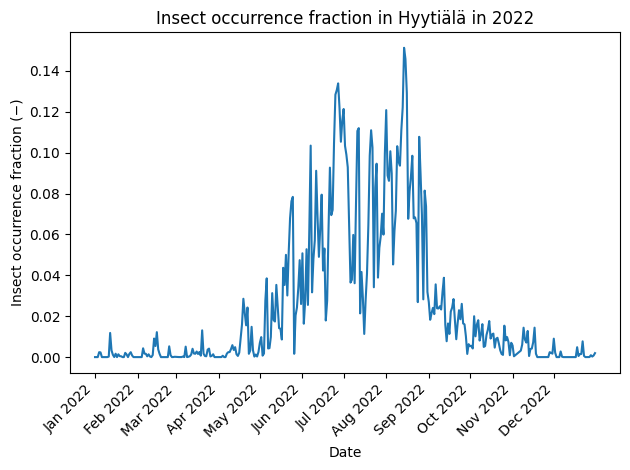

In [14]:
dates = []
insects = []
for p in sorted(outdir.iterdir()):
    with netCDF4.Dataset(p) as nc:
        n_total = np.prod(nc["target_classification"].shape)
        n_insects = np.count_nonzero(nc["target_classification"][:] == 9)
        n_aerosols_and_insects = np.count_nonzero(nc["target_classification"][:] == 10)
        dates.append(datetime.date(int(nc.year), int(nc.month), int(nc.day)))
        insects.append((n_insects + n_aerosols_and_insects) / n_total)
plt.plot(dates, insects)
plt.ylabel("Insect occurrence fraction (−)")
plt.xlabel("Date")
tick_dates = [d for i, d in enumerate(dates) if i == 0 or d.month != dates[i - 1].month]
tick_labels = [d.strftime("%b %Y") for d in tick_dates]
plt.xticks(tick_dates, tick_labels, rotation=45, ha="right")

plt.title("Insect occurrence fraction in Hyytiälä in 2022")

plt.tight_layout()
plt.show()